
🔹 First 5 rows:
                              Region                Country        Item Type  \
0              Australia and Oceania                 Tuvalu        Baby Food   
1  Central America and the Caribbean                Grenada           Cereal   
2                             Europe                 Russia  Office Supplies   
3                 Sub-Saharan Africa  Sao Tome and Principe           Fruits   
4                 Sub-Saharan Africa                 Rwanda  Office Supplies   

  Sales Channel Order Priority Order Date   Order ID  Ship Date  Units Sold  \
0       Offline              H  5/28/2010  669165933  6/27/2010        9925   
1        Online              C  8/22/2012  963881480  9/15/2012        2804   
2       Offline              L   5/2/2014  341417157   5/8/2014        1779   
3        Online              C  6/20/2014  514321792   7/5/2014        8102   
4       Offline              L   2/1/2013  115456712   2/6/2013        5062   

   Unit Price  Unit Cost  T

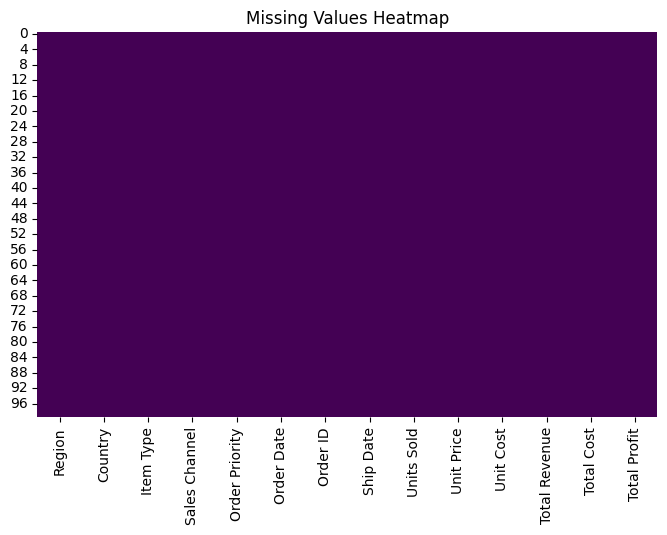

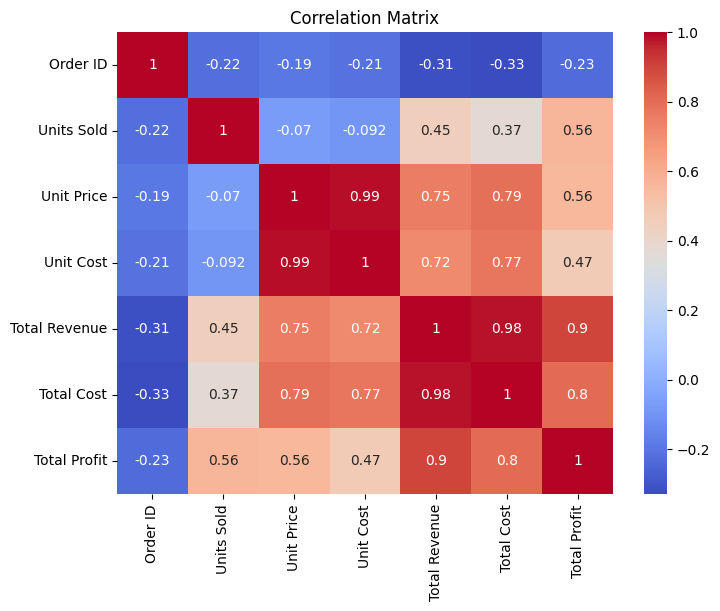


🔹 Outliers in Order ID: 0

🔹 Outliers in Units Sold: 0

🔹 Outliers in Unit Price: 0

🔹 Outliers in Unit Cost: 0

🔹 Outliers in Total Revenue: 3

🔹 Outliers in Total Cost: 3

🔹 Outliers in Total Profit: 5


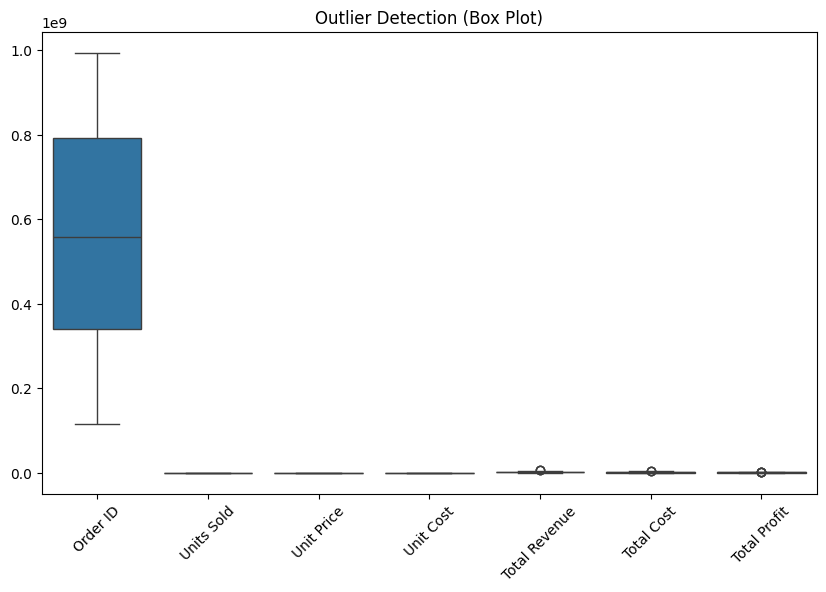

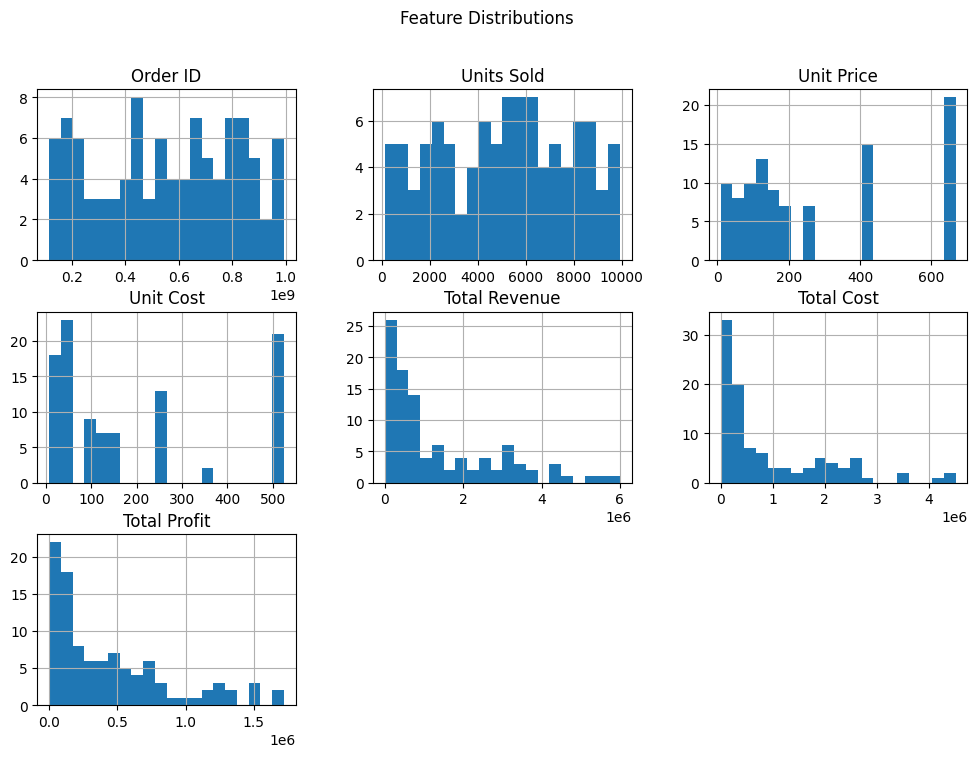

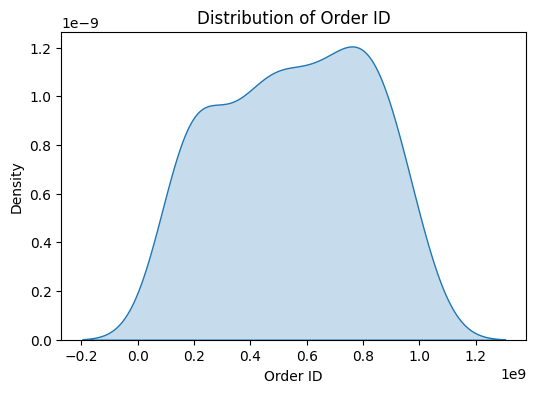

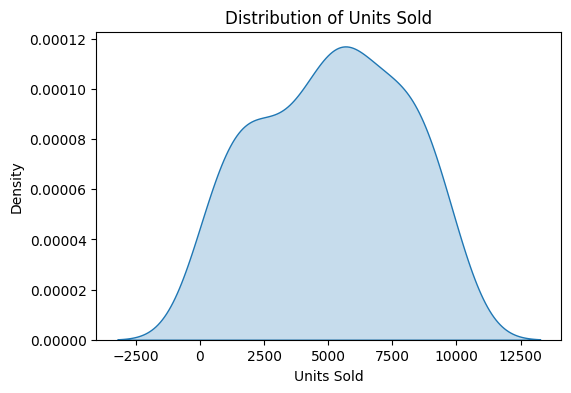

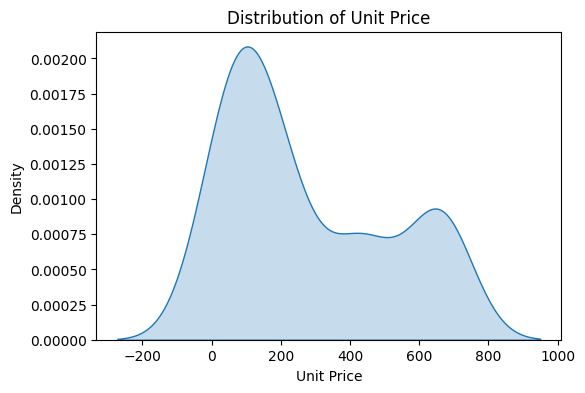

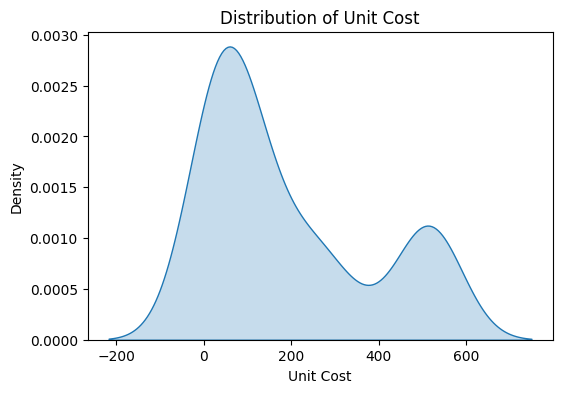

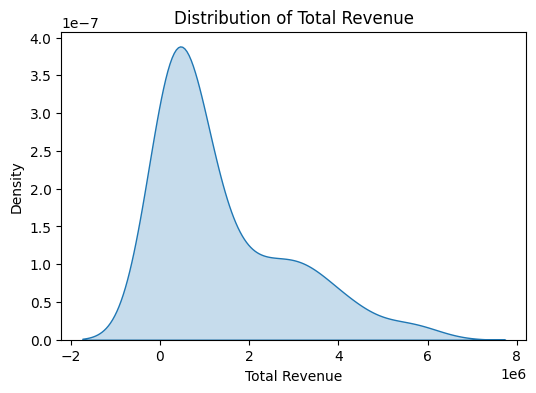

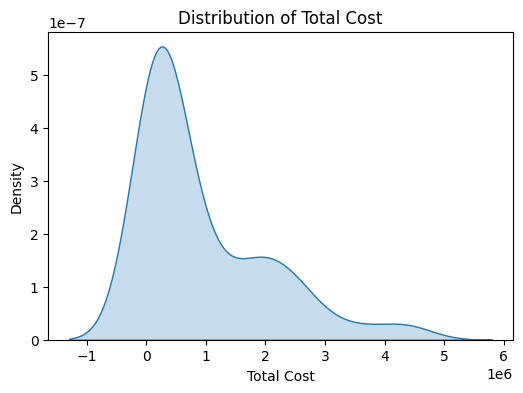

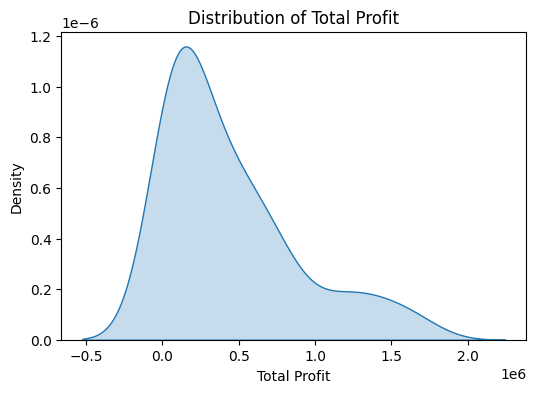

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# 1. LOAD DATASET
# ---------------------------
# Replace with your dataset
df = pd.read_csv(r"D:\Data Science with AI & ML\SITP-12th-May\PANDAS\sales.csv")

print("\n🔹 First 5 rows:")
print(df.head())

# ---------------------------
# 2. MISSING VALUES ANALYSIS
# ---------------------------
print("\n🔹 Missing Values Count:")
print(df.isnull().sum())

print("\n🔹 Missing Values Percentage:")
print((df.isnull().sum() / len(df)) * 100)

# Heatmap of missing values
plt.figure(figsize=(8, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

# ---------------------------
# 3. CORRELATION ANALYSIS
# ---------------------------
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# ---------------------------
# 4. OUTLIER DETECTION (IQR METHOD)
# ---------------------------
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[(data[column] < lower) | (data[column] > upper)]

# Apply on all numeric columns
for col in numeric_df.columns:
    outliers = detect_outliers_iqr(df, col)
    print(f"\n🔹 Outliers in {col}: {len(outliers)}")

# Boxplot for visualization
plt.figure(figsize=(10, 6))
sns.boxplot(data=numeric_df)
plt.title("Outlier Detection (Box Plot)")
plt.xticks(rotation=45)
plt.show()

# ---------------------------
# 5. FEATURE DISTRIBUTION VISUALIZATION
# ---------------------------
numeric_df.hist(bins=20, figsize=(12, 8))
plt.suptitle("Feature Distributions")
plt.show()

# KDE plots for better understanding
for col in numeric_df.columns:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(df[col], fill=True)
    plt.title(f"Distribution of {col}")
    plt.show()

Dataset Shape: (100, 14)

First 5 rows:
                               Region                Country        Item Type  \
0              Australia and Oceania                 Tuvalu        Baby Food   
1  Central America and the Caribbean                Grenada           Cereal   
2                             Europe                 Russia  Office Supplies   
3                 Sub-Saharan Africa  Sao Tome and Principe           Fruits   
4                 Sub-Saharan Africa                 Rwanda  Office Supplies   

  Sales Channel Order Priority Order Date   Order ID  Ship Date  Units Sold  \
0       Offline              H  5/28/2010  669165933  6/27/2010        9925   
1        Online              C  8/22/2012  963881480  9/15/2012        2804   
2       Offline              L   5/2/2014  341417157   5/8/2014        1779   
3        Online              C  6/20/2014  514321792   7/5/2014        8102   
4       Offline              L   2/1/2013  115456712   2/6/2013        5062   

   

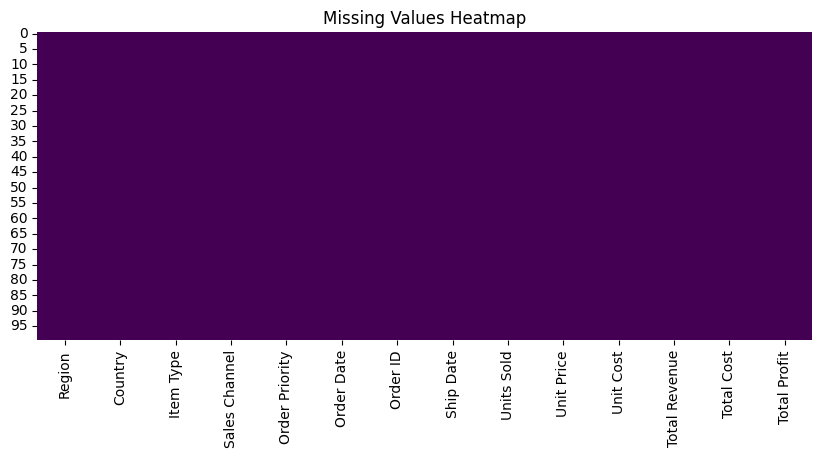


Correlation Matrix:
                Order ID  Units Sold  Unit Price  Unit Cost  Total Revenue  \
Order ID       1.000000   -0.222907   -0.190941  -0.213201      -0.314688   
Units Sold    -0.222907    1.000000   -0.070486  -0.092232       0.447784   
Unit Price    -0.190941   -0.070486    1.000000   0.987270       0.752360   
Unit Cost     -0.213201   -0.092232    0.987270   1.000000       0.715623   
Total Revenue -0.314688    0.447784    0.752360   0.715623       1.000000   
Total Cost    -0.328944    0.374746    0.787905   0.774895       0.983928   
Total Profit  -0.234638    0.564550    0.557365   0.467214       0.897327   

               Total Cost  Total Profit  
Order ID        -0.328944     -0.234638  
Units Sold       0.374746      0.564550  
Unit Price       0.787905      0.557365  
Unit Cost        0.774895      0.467214  
Total Revenue    0.983928      0.897327  
Total Cost       1.000000      0.804091  
Total Profit     0.804091      1.000000  


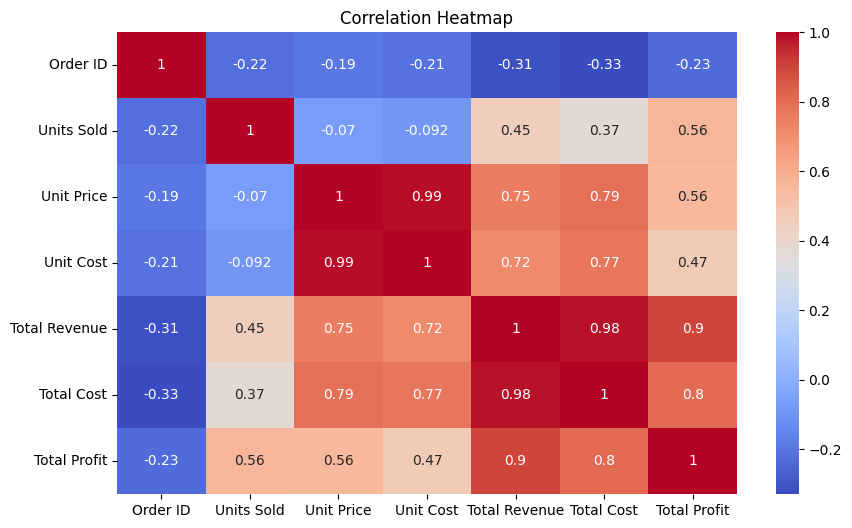


 Outlier Summary
Lower Bound: -2646263.9925
Upper Bound: 5127029.8875
Number of Outliers: 3


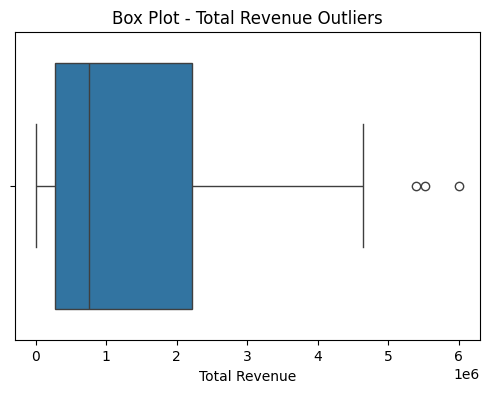

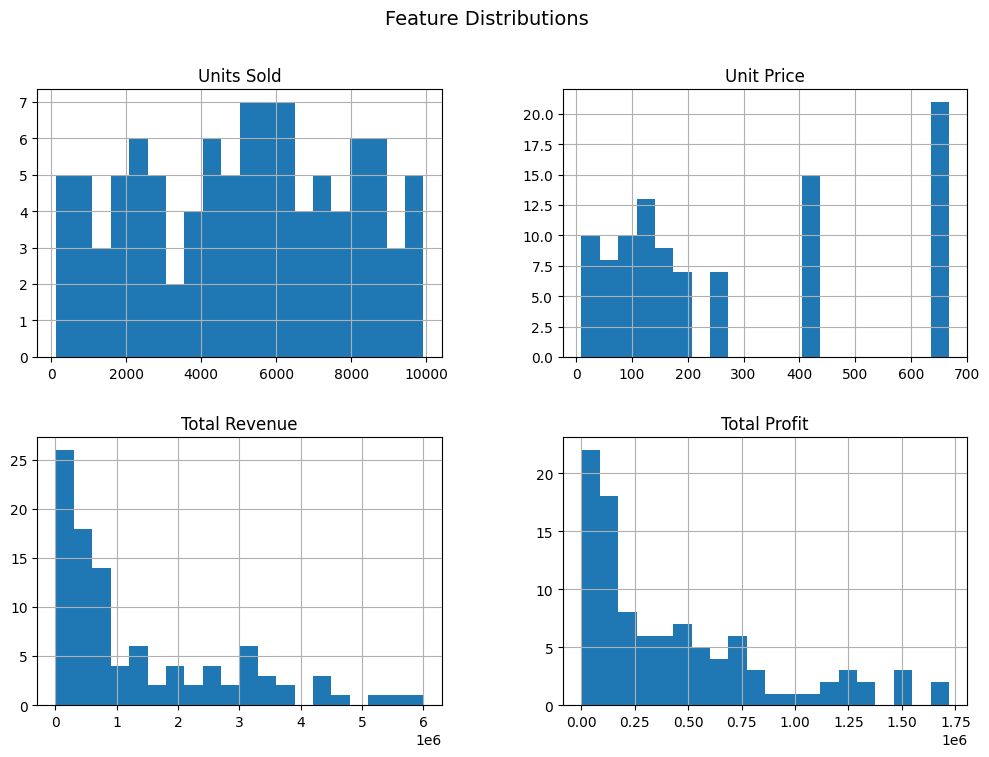


 Mini EDA Report Completed Successfully.


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv(r"D:\Data Science with AI & ML\SITP-12th-May\PANDAS\sales.csv")
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
# MISSING VALUES ANALYSIS
print("\n Missing Values:\n")
print(df.isnull().sum())
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()
# CORRELATION ANALYSIS
num_df = df.select_dtypes(include=["int64", "float64"])
corr = num_df.corr()
print("\nCorrelation Matrix:\n", corr)
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
# OUTLIER DETECTION 
col = "Total Revenue"
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
print("\n Outlier Summary")
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))
plt.figure(figsize=(6,4))
sns.boxplot(x=df[col])
plt.title("Box Plot - Total Revenue Outliers")
plt.show()
# FEATURE DISTRIBUTION
num_cols = ["Units Sold", "Unit Price", "Total Revenue", "Total Profit"]
df[num_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Feature Distributions", fontsize=14)
plt.show()
# END OF EDA REPORT
print("\n Mini EDA Report Completed Successfully.")